# Audio Classification: MotoSense


## 1. Library & Konfigurasi

In [1]:
import os, glob, shutil, random, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import json
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
# import tensorflowjs as tfjs
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Sequential, layers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import joblib # Needed to load the .joblib scaler file
import os
import pickle
import io
from IPython.display import display, Audio, clear_output
import ipywidgets as widgets
from audiomentations import (
    Compose,
    AddGaussianNoise,
    LowPassFilter,
    BandPassFilter,
    ClippingDistortion,
    Gain,
    PitchShift,
    TimeStretch,
    Shift,
    PolarityInversion,
    OneOf
)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import distutils.util
import matplotlib.gridspec as gridspec
import tensorflow_hub as hub
import numpy as np
import os
import glob
import librosa
import tensorflow as tf
from tensorflow.keras import layers, Sequential, regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ── Konfigurasi ──────────────────────────────────────────────


BASE_DIR      = "dataset"
TARGET_SR     = 16000
DURATION      = 2
TARGET_SAMPLES = TARGET_SR * DURATION  # 48.000
STRIDE_SAMPLES = int(TARGET_SR * 1.5)

CLASSES       = ["Clutch-Shoe", "Conecting-Rod", "Drive-Belt",
                 "Piston", "Tensioner", "Slider", "Roller", "Face-Drive"]

# NUM_CLASSES = len(CLASSES)

# Mel-Spectrogram — shape output: (128, 128)
N_MELS       = 128
N_FFT        = 1024
HOP_LENGTH   = 375  # 48000 / 375 = 128 frame tepat

# Augmentasi
AUG_TARGET   = 500  # minimal per kelas di training

# Training
BATCH_SIZE   = 8
EPOCHS       = 100
SEED         = 42

# ── Folder paths ─────────────────────────────────────────────
PATHS = {
    "raw"         : os.path.join(BASE_DIR, "part-rusak"),
    "rename"      : os.path.join(BASE_DIR, "rename"),
    "split_orig"  : os.path.join(BASE_DIR, "split_original"),
    "prep_train"  : os.path.join(BASE_DIR, "preprocesed", "train"),
    "prep_val"    : os.path.join(BASE_DIR, "preprocesed", "val"),
    "prep_test"   : os.path.join(BASE_DIR, "preprocesed", "test"),
    "aug_train"   : os.path.join(BASE_DIR, "augmented", "train"),
    "features"    : os.path.join(BASE_DIR, "features"),
    "models"      : "models",
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

# print(f"TensorFlow  : {tf.__version__}")
# print(f"GPU         : {tf.config.list_physical_devices('GPU') or 'CPU'}")
# print(f"Target shape: ({N_MELS}, {TARGET_SAMPLES // HOP_LENGTH}, 1)")

## 2. Rename File

In [2]:
for cls in CLASSES:
    src = os.path.join(PATHS['raw'], cls)
    dst = os.path.join(PATHS['rename'], cls)
    os.makedirs(dst, exist_ok=True)
    files = sorted(f for f in os.listdir(src) if f.endswith(('.wav','.mp3','.m4a')))
    for i, f in enumerate(files, 1):
        ext = os.path.splitext(f)[1]
        shutil.copy(os.path.join(src, f),
                    os.path.join(dst, f"{cls.lower()}-{i:03d}{ext}"))
    print(f"  {cls:<15}: {len(files)} file")

print(f"\nDisimpan ke: {PATHS['rename']}")

  Clutch-Shoe    : 15 file
  Conecting-Rod  : 10 file
  Drive-Belt     : 20 file
  Piston         : 6 file
  Tensioner      : 8 file
  Slider         : 13 file
  Roller         : 19 file
  Face-Drive     : 9 file

Disimpan ke: dataset/rename


## EDA

In [3]:
durasi_dict = {}

print(f"{'KELAS':<15} | {'FILE':<5} | {'SAMPLE RATE':<12} | {'RATA-RATA':<10} | {'MIN':<6} | {'MAX':<6}")
print("-" * 80)

for cls in sorted(os.listdir(PATHS["raw"])):

    path = os.path.join(PATHS["raw"], cls)

    if not os.path.isdir(path):
        continue

    files = [
        f for f in os.listdir(path)
        if f.lower().endswith((".wav", ".mp3", ".m4a"))
    ]

    if len(files) == 0:
        continue

    durasi_list = [
        librosa.get_duration(path=os.path.join(path, f))
        for f in files
    ]

    _, sr = librosa.load(
        os.path.join(path, files[0]),
        sr=None
    )

    durasi_dict[cls] = durasi_list

    print(
        f"{cls:<15} | "
        f"{len(files):<5} | "
        f"{sr:<12} | "
        f"{np.mean(durasi_list):<8.2f}s | "
        f"{np.min(durasi_list):<4.2f}s | "
        f"{np.max(durasi_list):<4.2f}s"
    )

KELAS           | FILE  | SAMPLE RATE  | RATA-RATA  | MIN    | MAX   
--------------------------------------------------------------------------------
Clutch-Shoe     | 15    | 44100        | 2.51    s | 1.07s | 4.08s
Conecting-Rod   | 10    | 44100        | 2.37    s | 1.62s | 4.21s
Drive-Belt      | 20    | 44100        | 3.55    s | 1.60s | 6.75s
Face-Drive      | 9     | 44100        | 3.14    s | 1.20s | 4.82s
Piston          | 6     | 44100        | 1.74    s | 1.00s | 3.17s
Roller          | 19    | 44100        | 3.78    s | 1.53s | 9.15s
Slider          | 13    | 44100        | 3.91    s | 0.84s | 6.51s
Tensioner       | 8     | 44100        | 2.97    s | 1.59s | 7.41s


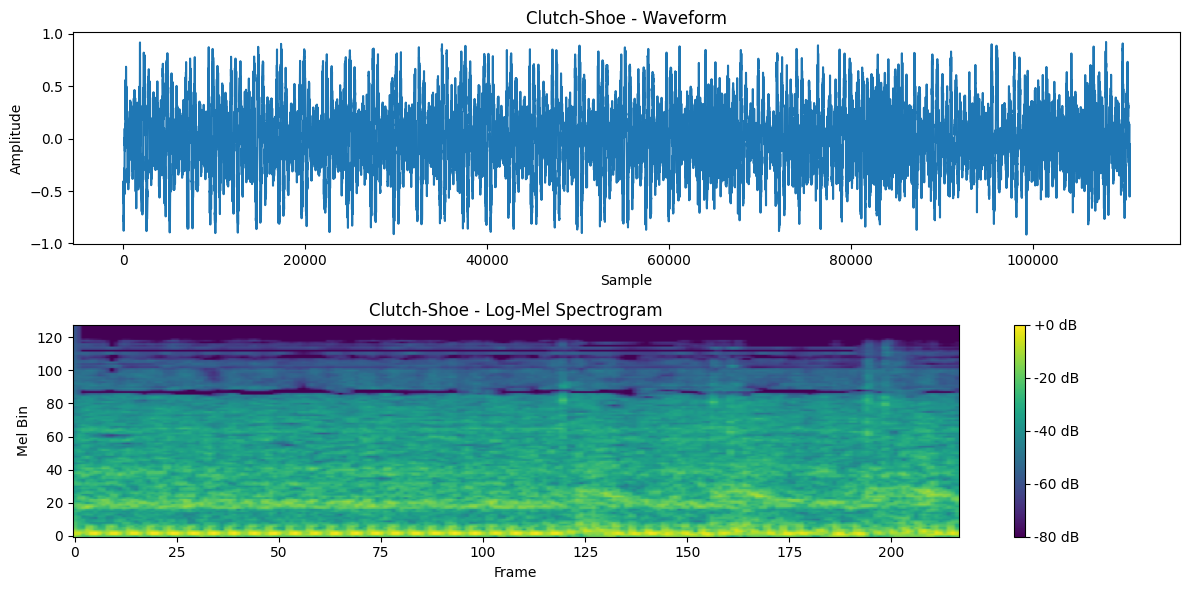

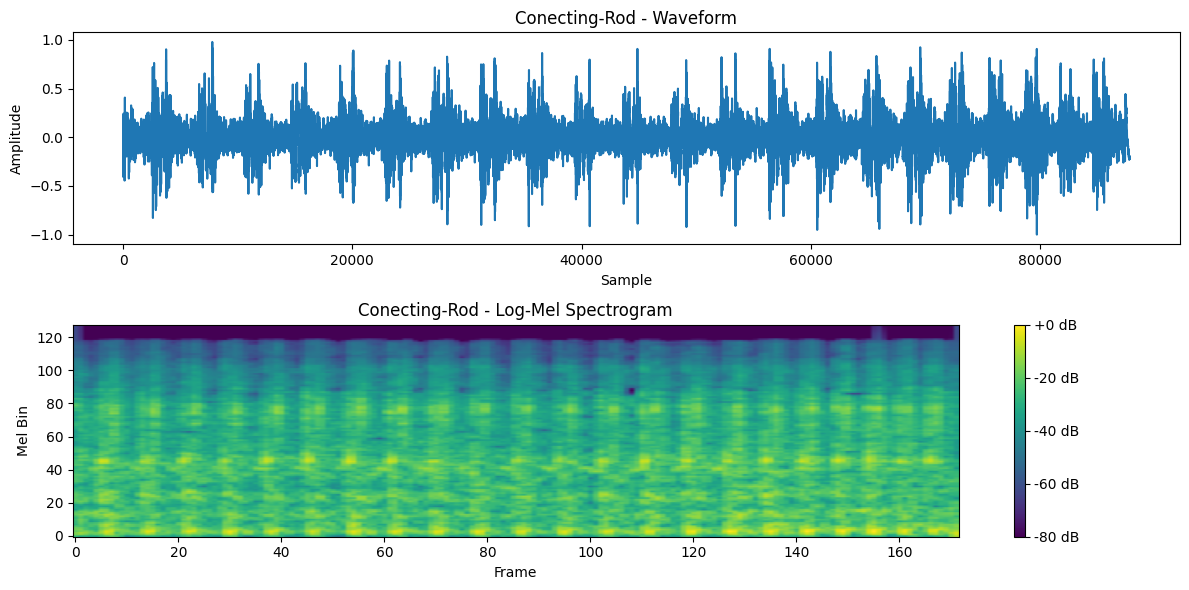

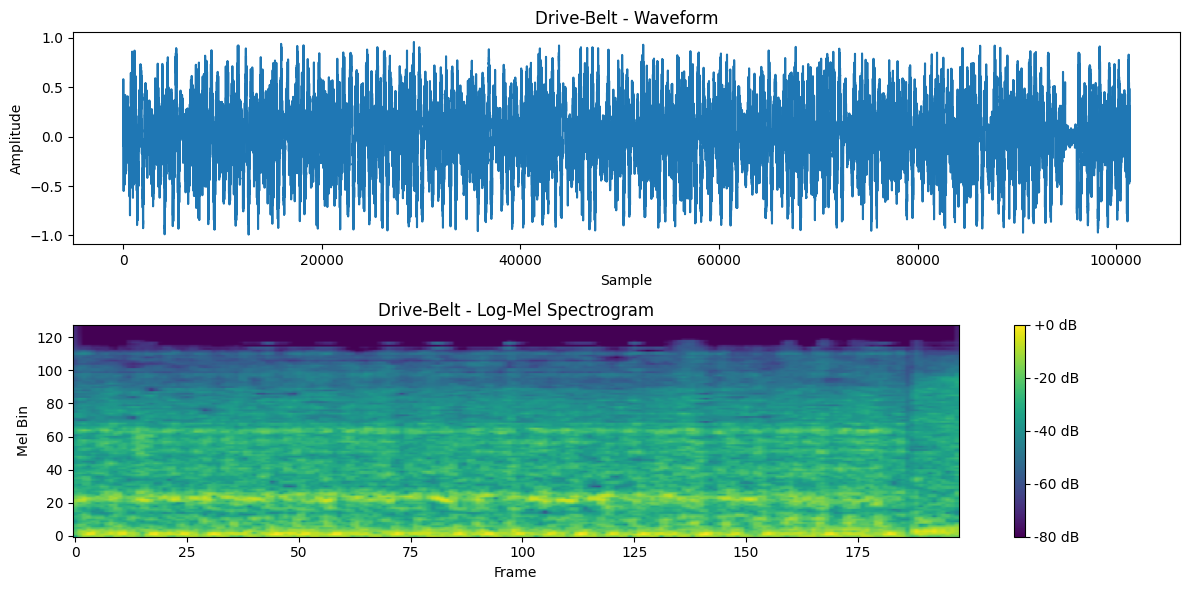

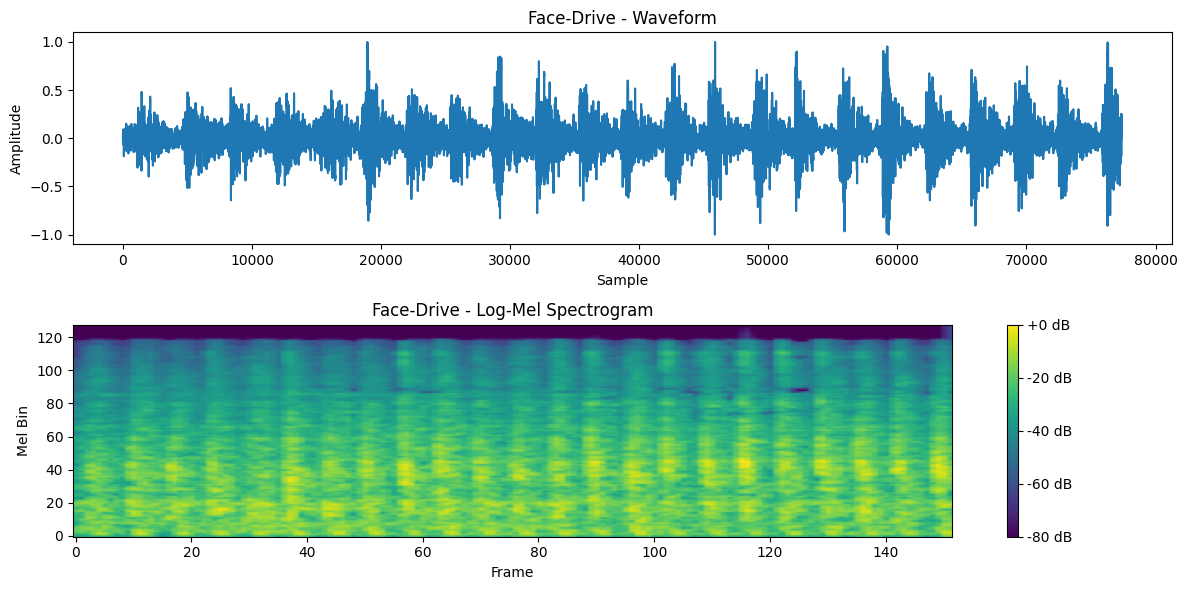

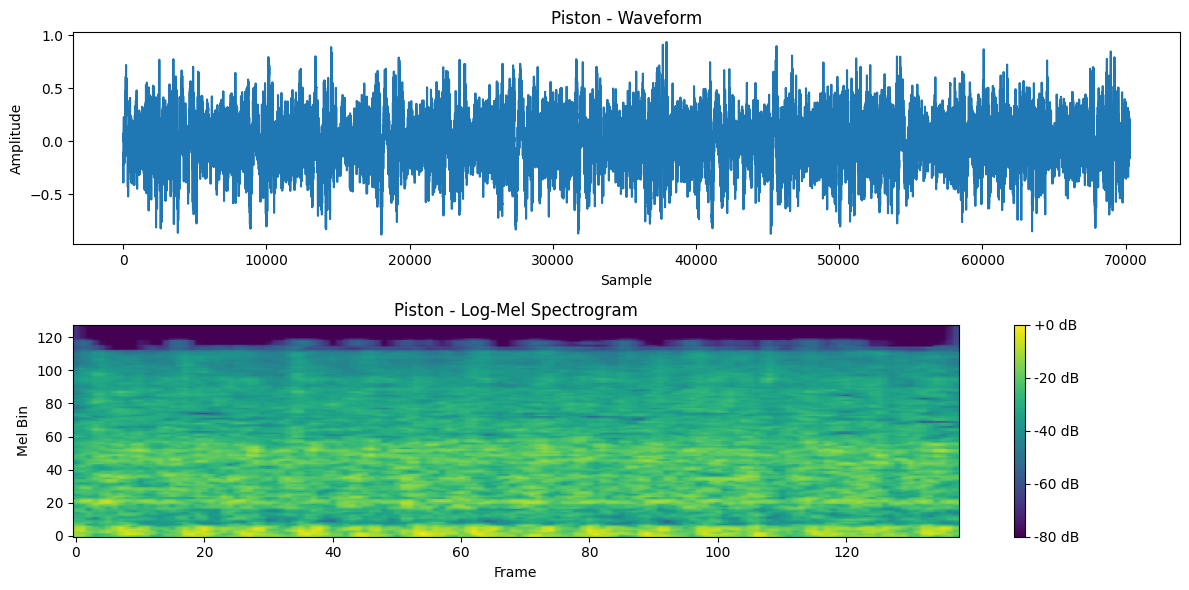

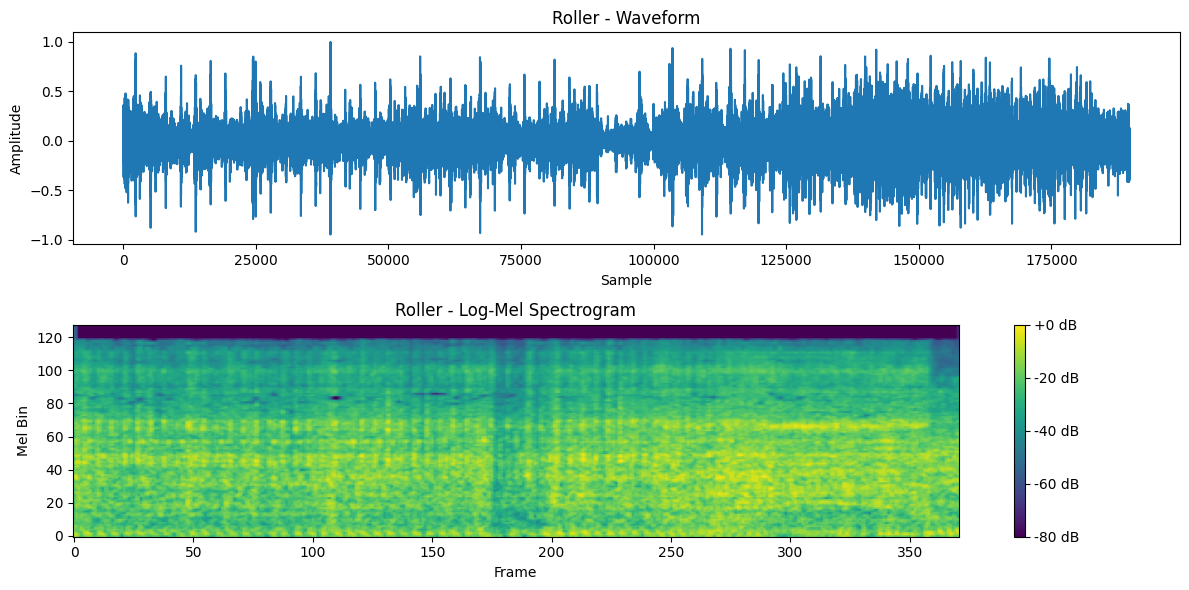

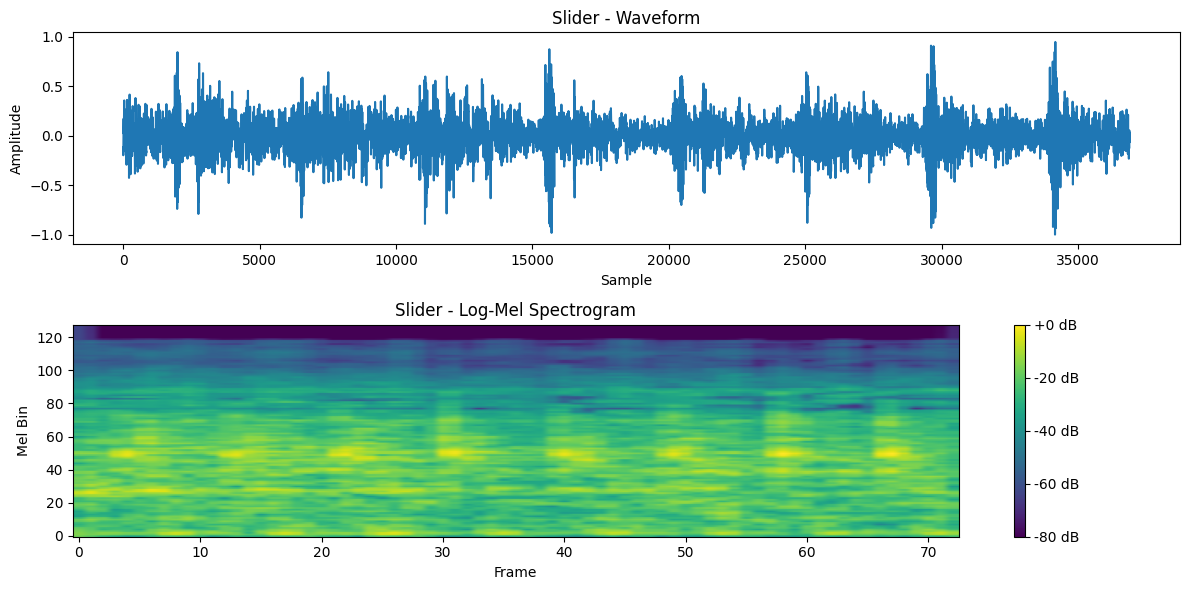

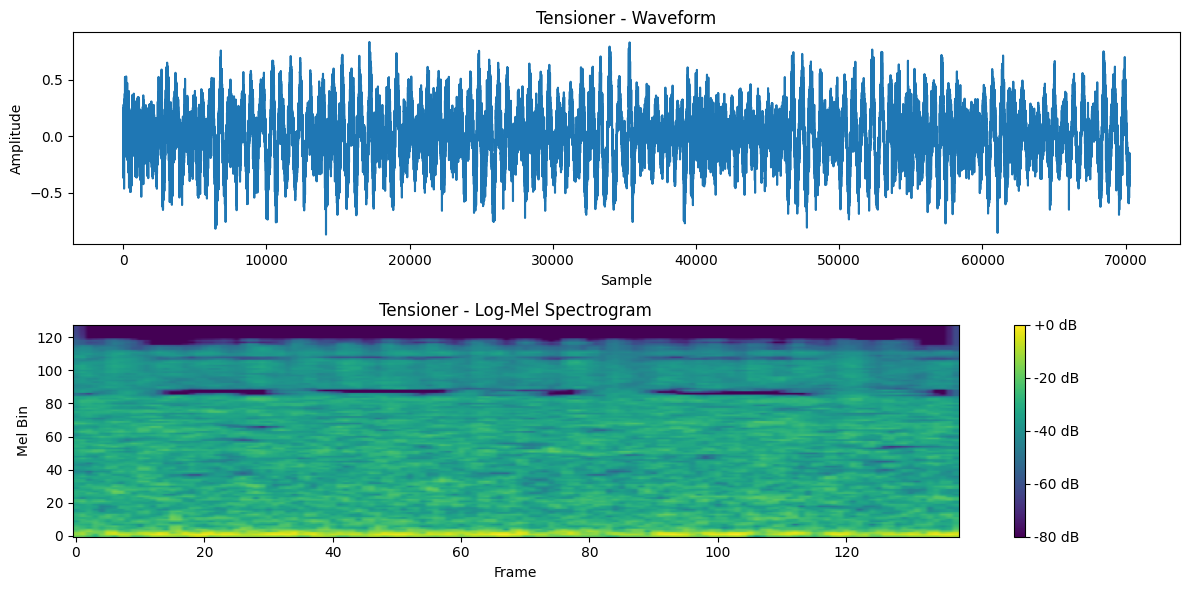

In [4]:
for cls in sorted(os.listdir(PATHS["raw"])):

    path = os.path.join(PATHS["raw"], cls)

    if not os.path.isdir(path):
        continue

    files = sorted([
        f for f in os.listdir(path)
        if f.lower().endswith((".wav", ".mp3", ".m4a"))
    ])

    if len(files) == 0:
        continue

    sample_file = os.path.join(path, files[0])

    y, sr = librosa.load(
        sample_file,
        sr=None
    )

    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )

    log_mel_spec = librosa.power_to_db(
        mel_spec,
        ref=np.max
    )

    plt.figure(figsize=(12, 6))

    # Waveform
    plt.subplot(2, 1, 1)
    plt.plot(y)
    plt.title(f"{cls} - Waveform")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")

    # Spectrogram
    plt.subplot(2, 1, 2)
    plt.imshow(
        log_mel_spec,
        aspect="auto",
        origin="lower"
    )

    plt.title(f"{cls} - Log-Mel Spectrogram")
    plt.xlabel("Frame")
    plt.ylabel("Mel Bin")
    plt.colorbar(format="%+2.0f dB")

    plt.tight_layout()
    plt.show()

## 4. Train/Val/Test Split

Split data awal untuk mencegah data leakage.

In [5]:
all_files, all_labels = [], []
for lbl, cls in enumerate(CLASSES):
    for f in glob.glob(os.path.join(PATHS['rename'], cls, '*.wav')):
        all_files.append(f)
        all_labels.append(lbl)

# Split: 70 / 15 / 15
X_tmp, X_test, y_tmp, y_test = train_test_split(
    all_files, all_labels, test_size=0.15, stratify=all_labels, random_state=SEED)
X_train, X_val, y_train_raw, y_val_raw = train_test_split(
    X_tmp, y_tmp, test_size=0.176, stratify=y_tmp, random_state=SEED)

# Menyalin file asli ke masing-masing folder split
for name, files, labels in [("train", X_train, y_train_raw),
                              ("val",   X_val,   y_val_raw),
                              ("test",  X_test,  y_test)]:
    count = 0
    for f, l in zip(files, labels):
        cls = CLASSES[l]
        dst_dir = os.path.join(PATHS['split_orig'], name, cls)
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(f, os.path.join(dst_dir, os.path.basename(f)))
        count += 1
    print(f"  {name:<6}: {count:>3} file disalin ke {os.path.join(PATHS['split_orig'], name)}")

print(f"\nTotal file asli: {len(all_files)}")

  train :  70 file disalin ke dataset/split_original/train
  val   :  15 file disalin ke dataset/split_original/val
  test  :  15 file disalin ke dataset/split_original/test

Total file asli: 100


## 5. Preprocessing & Chunking

Sliding window chunking (3 detik) untuk tiap subset.

In [6]:
def preprocess(path):
    y, _ = librosa.load(path, sr=TARGET_SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    peak  = np.max(np.abs(y))
    return y / peak if peak > 0 else y

def chunk_and_save(src_base, out_base):
    total = 0
    for cls in CLASSES:
        src_dir = os.path.join(src_base, cls)
        dst_dir = os.path.join(out_base, cls)
        os.makedirs(dst_dir, exist_ok=True)
        
        files = glob.glob(os.path.join(src_dir, '*.wav'))
        for f in files:
            audio  = preprocess(f)
            base   = os.path.splitext(os.path.basename(f))[0]

            # Sliding window
            audio_len = len(audio)
            if audio_len < TARGET_SAMPLES:
                audio = np.tile(audio, int(np.ceil(TARGET_SAMPLES / audio_len)))
            chunks = [audio[i:i+TARGET_SAMPLES]
                      for i in range(0, len(audio)-TARGET_SAMPLES+1, STRIDE_SAMPLES)
                      if len(audio[i:i+TARGET_SAMPLES]) == TARGET_SAMPLES]
            for ci, chunk in enumerate(chunks):
                sf.write(os.path.join(dst_dir, f"{base}_c{ci}.wav"), chunk, TARGET_SR, subtype='PCM_16')
                total += 1
    return total

for subset, out_key in [("train", "prep_train"), ("val", "prep_val"), ("test", "prep_test")]:
    src_base = os.path.join(PATHS['split_orig'], subset)
    n = chunk_and_save(src_base, PATHS[out_key])
    print(f"  {subset:<6}: {n} chunks → {PATHS[out_key]}")

print("\nChunking selesai")

  train : 116 chunks → dataset/preprocesed/train
  val   : 19 chunks → dataset/preprocesed/val
  test  : 24 chunks → dataset/preprocesed/test

Chunking selesai


## 6. Augmentation

Hanya diterapkan pada data training.

In [7]:
augment = Compose([
    # 1) Noise lingkungan / sensor
    OneOf([
        AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.010, p=1.0),
        # Jika Anda punya noise folder, AddBackgroundNoise lebih bagus daripada GaussianNoise
        # AddBackgroundNoise(sounds_path="Dataset/noise", min_snr_in_db=5, max_snr_in_db=25, p=1.0),
    ], p=0.80),

    # 2) Distorsi mikrofon / jarak rekaman
    OneOf([
        LowPassFilter(min_cutoff_freq=2500, max_cutoff_freq=8000, p=1.0),
        BandPassFilter(min_center_freq=300, max_center_freq=6000, min_bandwidth_fraction=0.4, max_bandwidth_fraction=0.9, p=1.0),
        ClippingDistortion(max_percentile_threshold=5, p=1.0),
    ], p=0.45),

    # 3) Variasi volume
    Gain(min_gain_db=-10, max_gain_db=8, p=0.70),

    # 4) Posisi / timing perekaman
    Shift(min_shift=-0.15, max_shift=0.15, rollover=True, p=0.55),

    # 5) Variasi mesin yang sangat ringan
    TimeStretch(min_rate=0.95, max_rate=1.05, p=0.25),
    PitchShift(min_semitones=-1, max_semitones=1, p=0.15),

    # 6) Opsional, efek kecil
    PolarityInversion(p=0.10),
])

for cls in CLASSES:
    src_dir = os.path.join(PATHS['prep_train'], cls)
    dst_dir = os.path.join(PATHS['aug_train'], cls)
    os.makedirs(dst_dir, exist_ok=True)

    existing = glob.glob(os.path.join(src_dir, '*.wav'))
    if len(existing) == 0:
        print(f"  {cls:<15}: tidak ada file, dilewati")
        continue

    # Salin file asli
    for f in existing:
        shutil.copy(f, os.path.join(dst_dir, os.path.basename(f)))

    needed = max(0, AUG_TARGET - len(existing))

    for i in range(needed):
        src_file = random.choice(existing)
        y, _ = librosa.load(src_file, sr=TARGET_SR, mono=True)

        y_aug = augment(samples=y.astype(np.float32), sample_rate=TARGET_SR)

        # Samakan panjang
        if len(y_aug) < TARGET_SAMPLES:
            y_aug = np.pad(y_aug, (0, TARGET_SAMPLES - len(y_aug)))
        else:
            y_aug = y_aug[:TARGET_SAMPLES]

        out_path = os.path.join(dst_dir, f"aug_{i:05d}.wav")
        sf.write(out_path, y_aug, TARGET_SR, subtype='PCM_16')

    final = len(glob.glob(os.path.join(dst_dir, '*.wav')))
    print(f"  {cls:<15}: {len(existing):>3} asli → {final} total (+{needed} aug)")

print(f"\nDisimpan ke: {PATHS['aug_train']}")

  Clutch-Shoe    :  14 asli → 500 total (+486 aug)
  Conecting-Rod  :   7 asli → 500 total (+493 aug)
  Drive-Belt     :  24 asli → 500 total (+476 aug)
  Piston         :   4 asli → 500 total (+496 aug)
  Tensioner      :   9 asli → 500 total (+491 aug)
  Slider         :  24 asli → 500 total (+476 aug)
  Roller         :  23 asli → 500 total (+477 aug)
  Face-Drive     :  11 asli → 500 total (+489 aug)

Disimpan ke: dataset/augmented/train


## 7. Feature Extraction (Log-Mel Spectrogram)

Konversi audio ke matriks 2D (128x128).

### Visualisasi Spectrogram

Sample perbandingan waveform dan spectrogram.

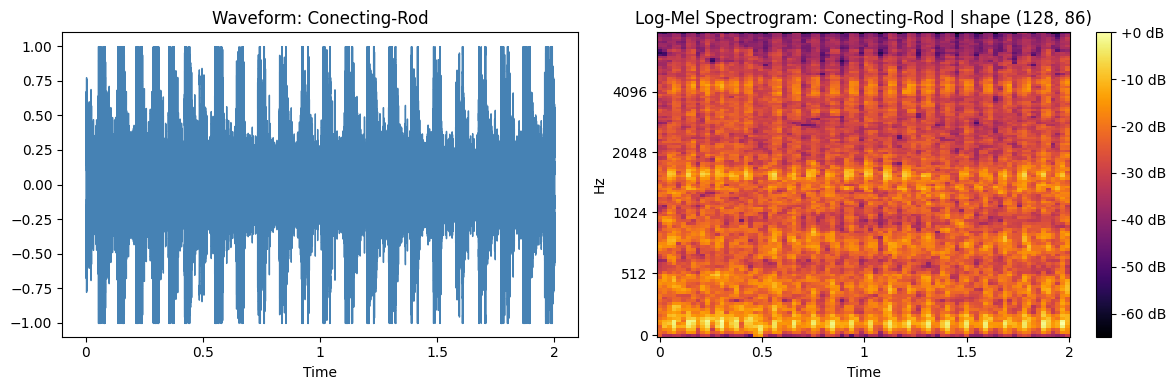

In [8]:
import random, matplotlib.pyplot as plt, librosa, librosa.display

sample_wavs = glob.glob(os.path.join(PATHS['aug_train'], '*', '*.wav'))
if sample_wavs:
    sample_path = random.choice(sample_wavs)
    cls_name    = os.path.basename(os.path.dirname(sample_path))
    y_s, sr_s   = librosa.load(sample_path, sr=TARGET_SR, mono=True)
    mel = librosa.feature.melspectrogram(y=y_s, sr=sr_s, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    db  = librosa.power_to_db(mel, ref=np.max)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    librosa.display.waveshow(y_s, sr=sr_s, ax=ax[0], color='steelblue')
    ax[0].set_title(f'Waveform: {cls_name}')
    img = librosa.display.specshow(db, sr=sr_s, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=ax[1], cmap='inferno')
    plt.colorbar(img, ax=ax[1], format='%+2.0f dB')
    ax[1].set_title(f'Log-Mel Spectrogram: {cls_name} | shape {db.shape}')
    plt.tight_layout(); plt.show()

### Feature Extraction with YAMNet


In [9]:

print("Memuat model YAMNet dari TF Hub...")
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print("YAMNet berhasil dimuat!")

def extract_yamnet_embeddings(data_dir):
    X, y = [], []
    for lbl, cls in enumerate(CLASSES):
        files = glob.glob(os.path.join(data_dir, cls, '*.wav'))
        for f in files:
            wav, _ = librosa.load(f, sr=16000, mono=True)
            wav = wav / (np.max(np.abs(wav)) + 1e-8)
            _, embeddings, _ = yamnet_model(wav)
            # emb_mean = np.mean(embeddings.numpy(), axis=0)
            emb = embeddings.numpy()

            emb_mean = np.mean(emb, axis=0)
            emb_std  = np.std(emb, axis=0)

            feature = np.concatenate([emb_mean, emb_std])
            X.append(emb_mean)
            y.append(lbl)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

YAMNET_FEAT = {
    "train": (os.path.join(PATHS['features'], 'X_train_yamnet.npy'), os.path.join(PATHS['features'], 'y_train_yamnet.npy')),
    "val"  : (os.path.join(PATHS['features'], 'X_val_yamnet.npy'),   os.path.join(PATHS['features'], 'y_val_yamnet.npy')),
    "test" : (os.path.join(PATHS['features'], 'X_test_yamnet.npy'),  os.path.join(PATHS['features'], 'y_test_yamnet.npy')),
}
SRC = {"train": PATHS['aug_train'], "val": PATHS['prep_val'], "test": PATHS['prep_test']}

print("\nEkstraksi fitur YAMNet...")
for subset, (xp, yp) in YAMNET_FEAT.items():
    if os.path.exists(xp):
        print(f"  {subset:<6}: cache ditemukan, skip")
    else:
        print(f"  {subset:<6}: mengekstrak...")
        X, y = extract_yamnet_embeddings(SRC[subset])
        np.save(xp, X); np.save(yp, y)
        print(f"  {subset:<6}: {X.shape} tersimpan")

X_train_yn = np.load(YAMNET_FEAT['train'][0]); y_train_yn = np.load(YAMNET_FEAT['train'][1])
X_val_yn   = np.load(YAMNET_FEAT['val'][0]);   y_val_yn   = np.load(YAMNET_FEAT['val'][1])
X_test_yn  = np.load(YAMNET_FEAT['test'][0]);  y_test_yn  = np.load(YAMNET_FEAT['test'][1])
print(f"\nX_train: {X_train_yn.shape} | X_val: {X_val_yn.shape} | X_test: {X_test_yn.shape}")

Memuat model YAMNet dari TF Hub...
YAMNet berhasil dimuat!

Ekstraksi fitur YAMNet...
  train : mengekstrak...
  train : (4000, 1024) tersimpan
  val   : mengekstrak...
  val   : (19, 1024) tersimpan
  test  : mengekstrak...
  test  : (24, 1024) tersimpan

X_train: (4000, 1024) | X_val: (19, 1024) | X_test: (24, 1024)


In [10]:
print("Train :", X_train_yn.shape)
print("Val   :", X_val_yn.shape)
print("Test  :", X_test_yn.shape)

Train : (4000, 1024)
Val   : (19, 1024)
Test  : (24, 1024)


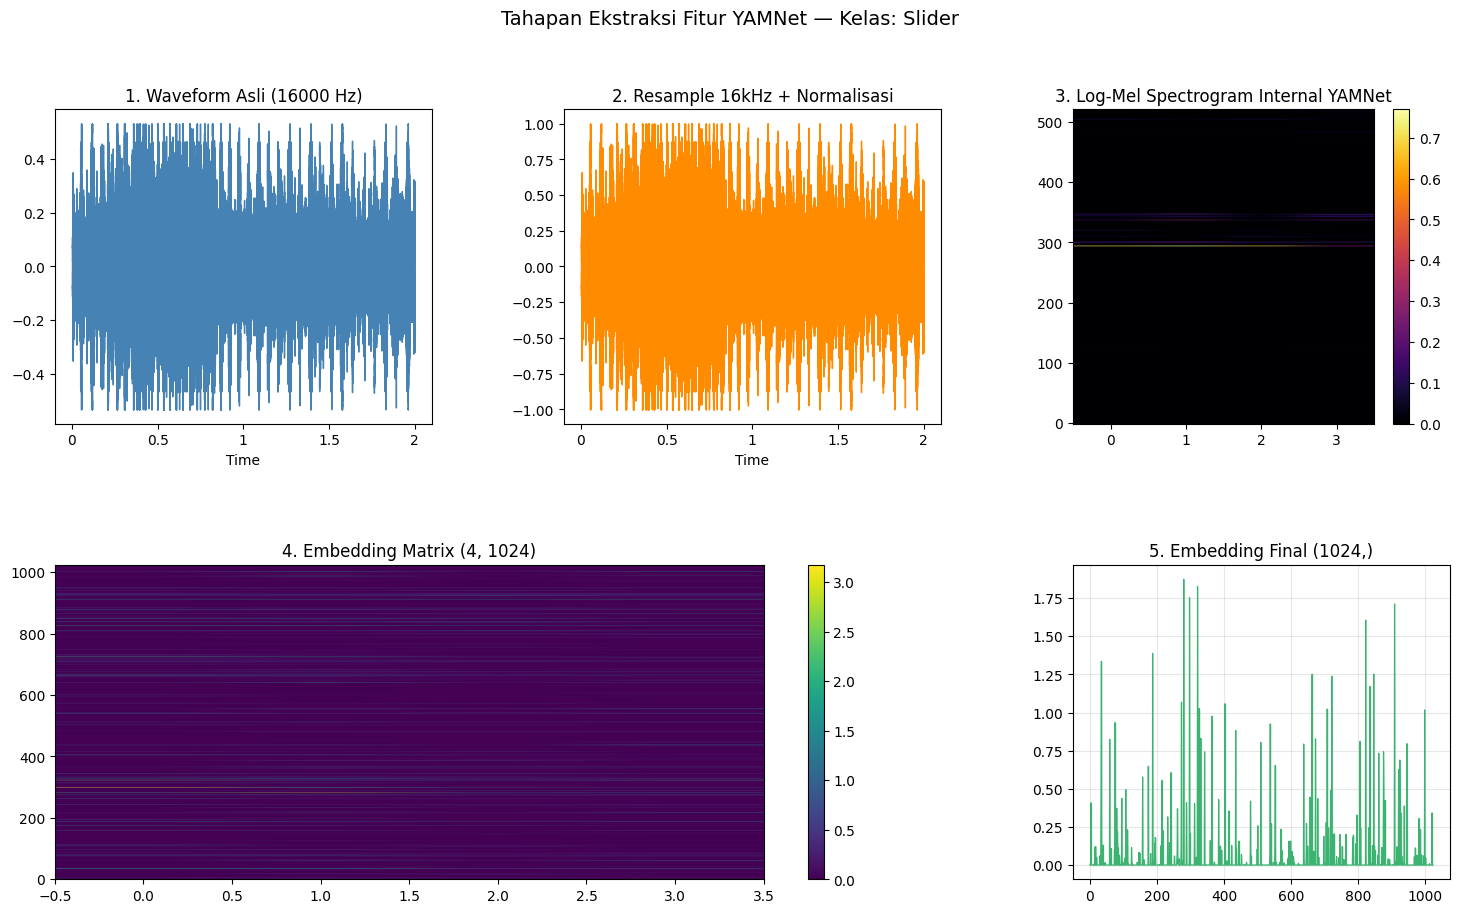

In [11]:


all_wavs = glob.glob(os.path.join(PATHS['aug_train'], '*', '*.wav'))
example_path = random.choice(all_wavs)
cls_name = os.path.basename(os.path.dirname(example_path))

wav_orig, sr_orig = librosa.load(example_path, sr=None, mono=True)
wav_16k, _ = librosa.load(example_path, sr=16000, mono=True)
wav_16k_norm = wav_16k / (np.max(np.abs(wav_16k)) + 1e-8)

log_mel_out, embeddings, _ = yamnet_model(wav_16k_norm)
emb_mean = np.mean(embeddings.numpy(), axis=0)

fig = plt.figure(figsize=(18, 10))
fig.suptitle(f'Tahapan Ekstraksi Fitur YAMNet — Kelas: {cls_name}', fontsize=14)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
librosa.display.waveshow(wav_orig, sr=sr_orig, ax=ax1, color='steelblue')
ax1.set_title(f'1. Waveform Asli ({sr_orig} Hz)')

ax2 = fig.add_subplot(gs[0, 1])
librosa.display.waveshow(wav_16k_norm, sr=16000, ax=ax2, color='darkorange')
ax2.set_title('2. Resample 16kHz + Normalisasi')

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(log_mel_out.numpy().T, origin='lower', aspect='auto', cmap='inferno')
plt.colorbar(im3, ax=ax3); ax3.set_title('3. Log-Mel Spectrogram Internal YAMNet')

ax4 = fig.add_subplot(gs[1, 0:2])
im4 = ax4.imshow(embeddings.numpy().T, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(im4, ax=ax4); ax4.set_title(f'4. Embedding Matrix {embeddings.numpy().shape}')

ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(emb_mean, color='mediumseagreen', linewidth=0.8)
ax5.fill_between(range(len(emb_mean)), emb_mean, alpha=0.3, color='mediumseagreen')
ax5.set_title(f'5. Embedding Final {emb_mean.shape}'); ax5.grid(alpha=0.3)
plt.show()

In [12]:
emb = embeddings.numpy()

print("Min :", emb.min())
print("Max :", emb.max())
print("Mean:", emb.mean())
print("Std :", emb.std())

Min : 0.0
Max : 3.1733563
Mean: 0.057739638
Std : 0.23568659


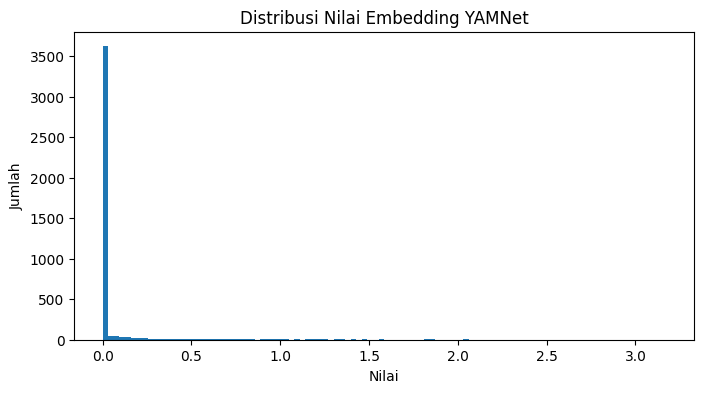

In [13]:
plt.figure(figsize=(8,4))
plt.hist(embeddings.numpy().flatten(), bins=100)
plt.title("Distribusi Nilai Embedding YAMNet")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.show()

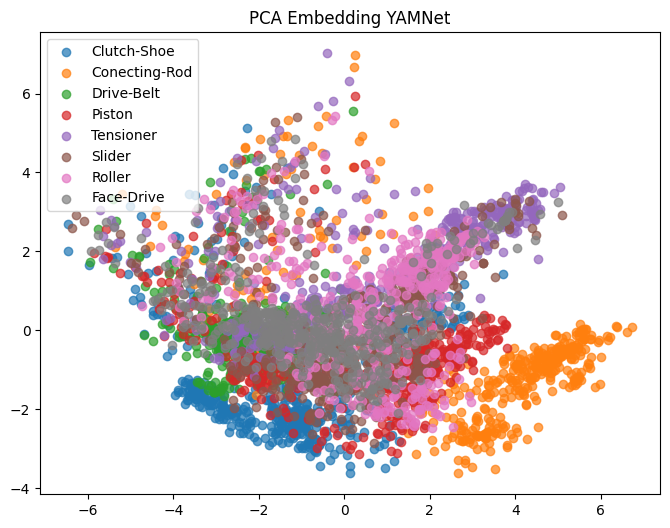

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_yn)

plt.figure(figsize=(8,6))

for i, cls in enumerate(CLASSES):
    idx = y_train_yn == i
    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=cls,
        alpha=0.7
    )

plt.legend()
plt.title("PCA Embedding YAMNet")
plt.show()

## 8. Training

### Standarisasi

In [15]:
scaler = StandardScaler()

X_train_sq = scaler.fit_transform(X_train_yn)

X_val_sq = scaler.transform(X_val_yn)

X_test_sq = scaler.transform(X_test_yn)

y_train_sq = y_train_yn
y_val_sq = y_val_yn
y_test_sq = y_test_yn


## 8.1 Dense Sequential model Arsitektur

In [16]:
def build_yamnet_classifier(n_classes):
    return Sequential([
        layers.Input(shape=(1024,)),
        layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation='softmax')
    ], 
    name="yamnet_dense")


### Traning & Callback 

Training YAMNet Dense Classifier...
Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6047 - loss: 1.2782 - val_accuracy: 0.8947 - val_loss: 0.6030 - learning_rate: 3.0000e-04
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7853 - loss: 0.7373 - val_accuracy: 0.8947 - val_loss: 0.4218 - learning_rate: 3.0000e-04
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8325 - loss: 0.5658 - val_accuracy: 0.8421 - val_loss: 0.3774 - learning_rate: 3.0000e-04
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8618 - loss: 0.4733 - val_accuracy: 0.8947 - val_loss: 0.4602 - learning_rate: 3.0000e-04
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8780 - loss: 0.4170 - val_accuracy: 0.8421 - val_loss: 0.4501 - learning_rate: 3.0000e-04
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8920 - loss: 0.3699 - val_accuracy: 0.8947 - val_loss: 0.4263 - learning_rate: 3.0000e-04
Epoch 7/100
500/500 ━━

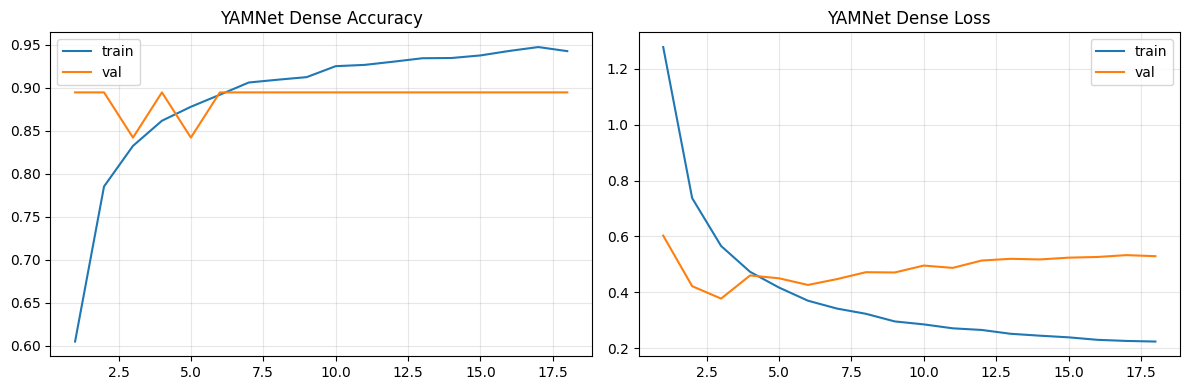

In [17]:

model_yn = build_yamnet_classifier(len(CLASSES))
model_yn.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks_yn = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print("Training YAMNet Dense Classifier...")
history_yn = model_yn.fit(
    X_train_yn, y_train_yn,
    validation_data=(X_val_yn, y_val_yn),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks_yn, verbose=1
)

loss, acc = model_yn.evaluate(X_test_yn, y_test_yn, verbose=0)
print(f"\nAkurasi YAMNet Dense pada Test Set: {acc*100:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history_yn.history['loss']) + 1)
ax[0].plot(ep, history_yn.history['accuracy'],     label='train')
ax[0].plot(ep, history_yn.history['val_accuracy'], label='val')
ax[0].set_title('YAMNet Dense Accuracy'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, history_yn.history['loss'],     label='train')
ax[1].plot(ep, history_yn.history['val_loss'], label='val')
ax[1].set_title('YAMNet Dense Loss'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Clasification Report

In [18]:
from sklearn.metrics import classification_report

y_pred = np.argmax(
    model_yn.predict(X_test_yn),
    axis=1
)

print(
    classification_report(
        y_test_yn,
        y_pred,
        target_names=CLASSES
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
               precision    recall  f1-score   support

  Clutch-Shoe       1.00      0.33      0.50         3
Conecting-Rod       1.00      1.00      1.00         3
   Drive-Belt       1.00      1.00      1.00         4
       Piston       1.00      1.00      1.00         1
    Tensioner       1.00      1.00      1.00         2
       Slider       0.50      1.00      0.67         2
       Roller       0.67      0.86      0.75         7
   Face-Drive       0.00      0.00      0.00         2

     accuracy                           0.79        24
    macro avg       0.77      0.77      0.74        24
 weighted avg       0.78      0.79      0.75        24



### confusion matriks

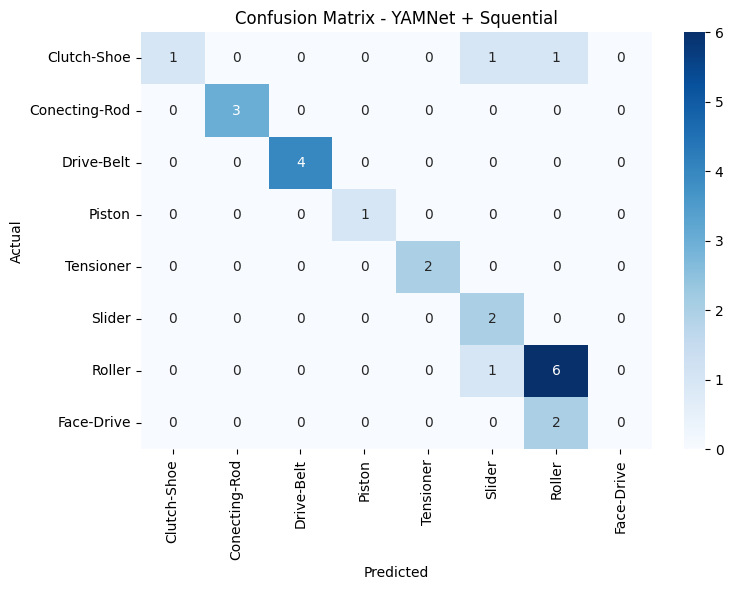

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test_sq, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap= 'Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - YAMNet + Squential")

plt.tight_layout()
plt.show()

### Save Model

In [20]:
import os

SEQ_DIRS = {
    'keras': os.path.join(PATHS['models'], 'sequential', 'keras'),
    'tflite': os.path.join(PATHS['models'], 'sequential', 'tflite'),
    'tfjs': os.path.join(PATHS['models'], 'sequential', 'tfjs'),
    'scaler': os.path.join(PATHS['models'], 'sequential', 'scaler'),
    'metadata': os.path.join(PATHS['models'], 'sequential', 'metadata'),
}

for path in SEQ_DIRS.values():
    os.makedirs(path, exist_ok=True)

print("="*70)
print("SETUP FOLDER MODEL SEQUENTIAL")
print("="*70)

for key, path in SEQ_DIRS.items():
    print(f"{key:<10}: {path}")

SETUP FOLDER MODEL SEQUENTIAL
keras     : models/sequential/keras
tflite    : models/sequential/tflite
tfjs      : models/sequential/tfjs
scaler    : models/sequential/scaler
metadata  : models/sequential/metadata


In [21]:
h5_path = os.path.join(
    SEQ_DIRS['keras'],
    'yamnet_sequential.h5'
)

model_yn.save(h5_path)

print(f"Saved H5 : {h5_path}")


keras_path = os.path.join(
    SEQ_DIRS['keras'],
    'yamnet_sequential.keras'
)

model_yn.save(keras_path)

print(f"Saved Keras : {keras_path}")


tflite_path = os.path.join(
    SEQ_DIRS['tflite'],
    'yamnet_sequential.tflite'
)

converter = tf.lite.TFLiteConverter.from_keras_model(
    model_yn
)

tflite_model = converter.convert()

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Saved TFLite : {tflite_path}")


# tfjs_path = os.path.join(
#     SEQ_DIRS['tfjs'],
#     'yamnet_sequential'
# )

# tfjs.converters.save_keras_model(
#     model_yn,
#     tfjs_path
# )

# print(f"Saved TFJS : {tfjs_path}")


import joblib

joblib.dump(
    scaler,
    os.path.join(
        SEQ_DIRS['scaler'],
        'yamnet_scaler.joblib'
    )
)

print("Scaler saved")

metadata = {
    "classes": CLASSES,
    "num_classes": len(CLASSES),
    "feature_extractor": "YAMNet",
    "embedding_size": int(X_train_yn.shape[1])

}


with open(
    os.path.join(
        SEQ_DIRS['metadata'],
        'metadata.json'
    ),
    'w'
) as f:
    json.dump(metadata, f, indent=4)

    

Saved H5 : models/sequential/keras/yamnet_sequential.h5
Saved Keras : models/sequential/keras/yamnet_sequential.keras
INFO:tensorflow:Assets written to: /var/folders/56/db9c3yn534757rq3twrpchw40000gn/T/tmpw5emaygj/assets


INFO:tensorflow:Assets written to: /var/folders/56/db9c3yn534757rq3twrpchw40000gn/T/tmpw5emaygj/assets


Saved artifact at '/var/folders/56/db9c3yn534757rq3twrpchw40000gn/T/tmpw5emaygj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  14298996112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14299001680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14299001488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14299002064: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved TFLite : models/sequential/tflite/yamnet_sequential.tflite
Scaler saved


## 8.2 SVM

In [22]:
from sklearn.preprocessing import StandardScaler

print("\nNormalisasi fitur YAMNet untuk SVM...")

scaler_svm = StandardScaler()

X_train_svm = scaler_svm.fit_transform(X_train_yn)
X_val_svm   = scaler_svm.transform(X_val_yn)
X_test_svm  = scaler_svm.transform(X_test_yn)

y_train_svm = y_train_yn
y_val_svm   = y_val_yn
y_test_svm  = y_test_yn

print("Normalisasi SVM selesai.")


Normalisasi fitur YAMNet untuk SVM...
Normalisasi SVM selesai.


In [23]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

print("Training SVM...")

svm_model.fit(X_train_svm, y_train_svm)

val_pred = svm_model.predict(X_val_svm)
val_acc = accuracy_score(y_val_svm, val_pred)

print(f"Validation Accuracy : {val_acc*100:.2f}%")

Training SVM...
Validation Accuracy : 89.47%


In [24]:
test_pred = svm_model.predict(X_test_svm)

test_acc = accuracy_score(y_test_svm, test_pred)

print(f"\nTest Accuracy : {test_acc*100:.2f}%")


Test Accuracy : 87.50%


In [25]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_svm,
        test_pred,
        target_names=CLASSES
    )
)

               precision    recall  f1-score   support

  Clutch-Shoe       1.00      0.33      0.50         3
Conecting-Rod       1.00      1.00      1.00         3
   Drive-Belt       1.00      1.00      1.00         4
       Piston       1.00      1.00      1.00         1
    Tensioner       1.00      1.00      1.00         2
       Slider       0.50      1.00      0.67         2
       Roller       0.88      1.00      0.93         7
   Face-Drive       1.00      0.50      0.67         2

     accuracy                           0.88        24
    macro avg       0.92      0.85      0.85        24
 weighted avg       0.92      0.88      0.86        24



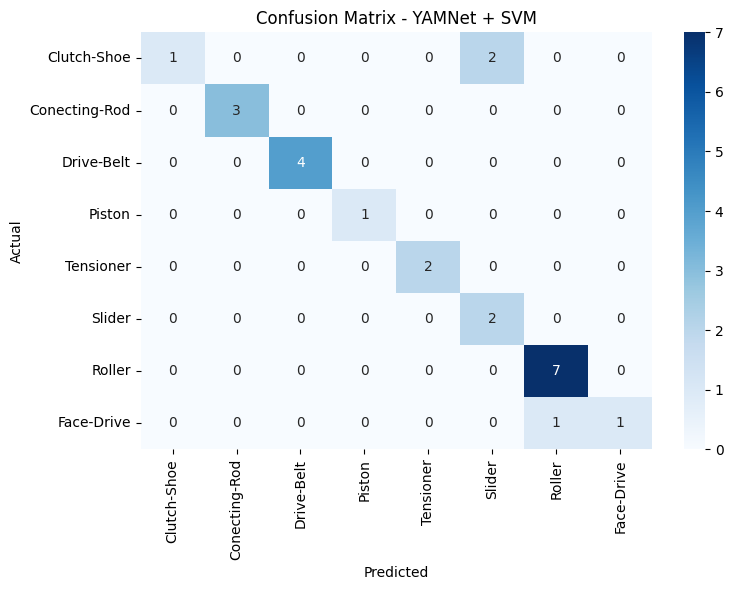

In [26]:


cm = confusion_matrix(y_test_svm, test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap= 'Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - YAMNet + SVM")

plt.tight_layout()
plt.show()

### Save Model

In [27]:
import os

SVM_DIRS = {
    'model': os.path.join(PATHS['models'], 'svm', 'model'),
    'scaler': os.path.join(PATHS['models'], 'svm', 'scaler'),
    'metadata': os.path.join(PATHS['models'], 'svm', 'metadata'),
}

for path in SVM_DIRS.values():
    os.makedirs(path, exist_ok=True)

print("="*70)
print("SETUP FOLDER MODEL SVM")
print("="*70)

for key, path in SVM_DIRS.items():
    print(f"{key:<10}: {path}")

SETUP FOLDER MODEL SVM
model     : models/svm/model
scaler    : models/svm/scaler
metadata  : models/svm/metadata


In [28]:
import joblib

svm_path = os.path.join(
    SVM_DIRS['model'],
    'yamnet_svm.joblib'
)

joblib.dump(
    svm_model,
    svm_path
)

print(f"Saved SVM : {svm_path}")

joblib.dump(
    scaler_svm,
    os.path.join(
        SVM_DIRS['scaler'],
        'yamnet_svm_scaler.joblib'
    )
)

print("SVM scaler saved")

with open(
    os.path.join(
        SVM_DIRS['metadata'],
        'metadata.json'
    ),
    'w'
) as f:
    json.dump(metadata, f, indent=4)

Saved SVM : models/svm/model/yamnet_svm.joblib
SVM scaler saved


## 8.3 Random Forest

In [29]:
print("\nPersiapan fitur untuk Random Forest...")

X_train_rf = X_train_yn.copy()
X_val_rf   = X_val_yn.copy()
X_test_rf  = X_test_yn.copy()

y_train_rf = y_train_yn
y_val_rf   = y_val_yn
y_test_rf  = y_test_yn




Persiapan fitur untuk Random Forest...


In [30]:


rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train_rf, y_train_rf)

val_pred_rf = rf_model.predict(X_val_rf)

val_acc_rf = accuracy_score(y_val_rf, val_pred_rf)

print(f"Validation Accuracy RF : {val_acc_rf*100:.2f}%")

test_pred_rf = rf_model.predict(X_test_rf)

test_acc_rf = accuracy_score(y_test_rf, test_pred_rf)

print(f"Test Accuracy RF : {test_acc_rf*100:.2f}%")

Training Random Forest...
Validation Accuracy RF : 89.47%
Test Accuracy RF : 83.33%


In [31]:

print(
    classification_report(
        y_test_rf,
        test_pred_rf,
        target_names=CLASSES
    )
)

               precision    recall  f1-score   support

  Clutch-Shoe       1.00      0.33      0.50         3
Conecting-Rod       1.00      1.00      1.00         3
   Drive-Belt       1.00      1.00      1.00         4
       Piston       1.00      1.00      1.00         1
    Tensioner       1.00      1.00      1.00         2
       Slider       0.67      1.00      0.80         2
       Roller       0.70      1.00      0.82         7
   Face-Drive       0.00      0.00      0.00         2

     accuracy                           0.83        24
    macro avg       0.80      0.79      0.77        24
 weighted avg       0.80      0.83      0.79        24



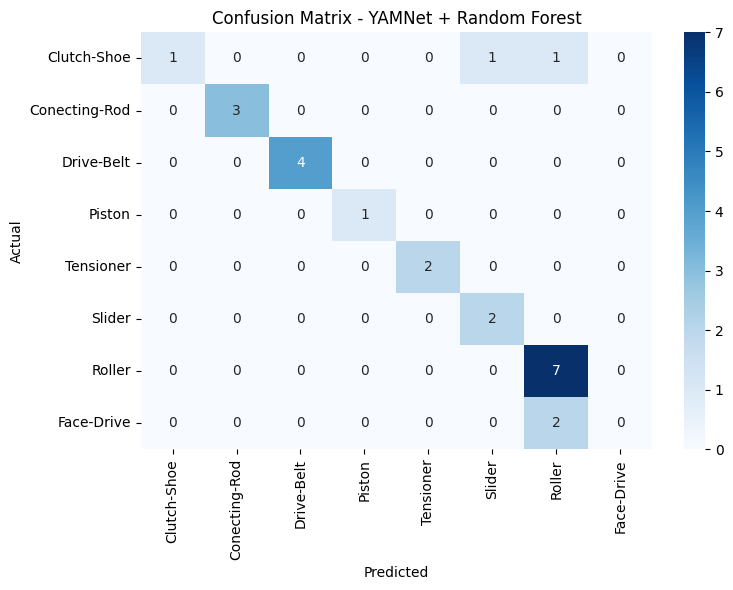

In [32]:


cm_rf = confusion_matrix(y_test_rf, test_pred_rf)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap= 'Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - YAMNet + Random Forest")

plt.tight_layout()
plt.show()

### Save Model

In [33]:
import os

RF_DIRS = {
    'model': os.path.join(PATHS['models'], 'random_forest', 'model'),
    'scaler': os.path.join(PATHS['models'], 'random_forest', 'scaler'),
    'metadata': os.path.join(PATHS['models'], 'random_forest', 'metadata'),
}

for path in RF_DIRS.values():
    os.makedirs(path, exist_ok=True)

print("="*70)
print("SETUP FOLDER MODEL RANDOM FOREST")
print("="*70)

for key, path in RF_DIRS.items():
    print(f"{key:<10}: {path}")

SETUP FOLDER MODEL RANDOM FOREST
model     : models/random_forest/model
scaler    : models/random_forest/scaler
metadata  : models/random_forest/metadata


In [34]:
import joblib

rf_path = os.path.join(
    RF_DIRS['model'],
    'yamnet_rf.joblib'
)

joblib.dump(
    rf_model,
    rf_path
)

print(f"Saved RF : {rf_path}")

with open(
    os.path.join(
        RF_DIRS['metadata'],
        'metadata.json'
    ),
    'w'
) as f:
    json.dump(metadata, f, indent=4)



Saved RF : models/random_forest/model/yamnet_rf.joblib


## Perbandingan Model

In [35]:

def evaluate_model(name, y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    prec = precision_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    rec = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    print(f"\n{name}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

evaluate_model(
    "Squential",
    y_test_sq,
    y_pred
)

evaluate_model(
    "SVM",
    y_test_yn,
    test_pred
)

evaluate_model(
    "Random Forest",
    y_test_yn,
    test_pred_rf
)



Squential
Accuracy  : 0.7917
Precision : 0.7778
Recall    : 0.7917
F1 Score  : 0.7535

SVM
Accuracy  : 0.8750
Precision : 0.9219
Recall    : 0.8750
F1 Score  : 0.8625

Random Forest
Accuracy  : 0.8333
Precision : 0.8014
Recall    : 0.8333
F1 Score  : 0.7860


## 10. Inference Pipeline

Pengujian model pada data raw `.wav`.

In [36]:


# def preprocess_audio_for_inference(audio_data, sample_rate=16000):
#     """
#     Memproses audio untuk inference:
#     1. Load audio dengan sample rate 16kHz
#     2. Normalisasi
#     3. Ekstraksi embedding YAMNet
    
#     Args:
#         audio_data: numpy array audio atau bytes
#         sample_rate: target sample rate
        
#     Returns:
#         embedding: numpy array shape (1024,)
#     """
#     # Jika audio_data adalah bytes, load dari buffer
#     if isinstance(audio_data, bytes):
#         wav, _ = librosa.load(io.BytesIO(audio_data), sr=sample_rate, mono=True)
#     else:
#         # Jika sudah numpy array
#         wav = audio_data
    
#     # Normalisasi
#     wav_norm = wav / (np.max(np.abs(wav)) + 1e-8)
    
#     # Ekstraksi embedding YAMNet
#     _, embeddings, _ = yamnet_model(wav_norm)
    
#     # Mean pooling
#     emb_mean = np.mean(embeddings.numpy(), axis=0)
    
#     return emb_mean, wav_norm

# def display_prediction_result(filename, model_name, predicted_class, confidence):
#     """
#     Menampilkan hasil prediksi dengan format yang rapi
#     """
#     print(f"\n{'='*60}")
#     print(f"Model: {model_name}")
#     print(f"{'='*60}")
#     print(f"Audio File    : {filename}")
#     print(f"Predicted     : {predicted_class}")
#     print(f"Confidence    : {confidence:.2%}")
#     print(f"{'='*60}\n")


In [37]:
# === 2. Load Sequential Model (TFLite) ===
print("\n2️⃣ Loading Sequential model...")
SEQ_MODEL_PATH = os.path.join(PATHS['models'], 'sequential', 'tflite', 'yamnet_sequential.tflite')

try:
    # Use TFLite Interpreter instead of Keras load_model
    interpreter = tf.lite.Interpreter(model_path=SEQ_MODEL_PATH)
    interpreter.allocate_tensors()
    
    # Get input and output tensor details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print(f"   ✅ Model loaded from: {SEQ_MODEL_PATH}")
    print(f"   ✅ Model input shape: {input_details[0]['shape']}")
    print(f"   ✅ Model output shape: {output_details[0]['shape']}")
except FileNotFoundError:
    print(f"   ❌ Model tidak ditemukan di: {SEQ_MODEL_PATH}")
    print(f"   💡 Pastikan model sudah disimpan terlebih dahulu")
except Exception as e:
    print(f"   ❌ Error loading model: {e}")

# === 3. Load Scaler ===
print("\n3️⃣ Loading Scaler...")
SCALER_PATH = os.path.join(PATHS['models'], 'sequential', 'scaler', 'yamnet_scaler.joblib')

try:
    # Using joblib directly is the standard way to load .joblib files
    scaler = joblib.load(SCALER_PATH)
    print(f"   ✅ Scaler loaded from: {SCALER_PATH}")
except FileNotFoundError:
    print(f"   ❌ Scaler tidak ditemukan di: {SCALER_PATH}")
    print(f"   💡 Pastikan scaler sudah disimpan terlebih dahulu")
except Exception as e:
    print(f"   ❌ Error loading scaler: {e}")


2️⃣ Loading Sequential model...
   ✅ Model loaded from: models/sequential/tflite/yamnet_sequential.tflite
   ✅ Model input shape: [   1 1024]
   ✅ Model output shape: [1 8]

3️⃣ Loading Scaler...
   ✅ Scaler loaded from: models/sequential/scaler/yamnet_scaler.joblib


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [38]:
# ==========================================
# 📦 0. IMPORT LIBRARY & PERSIAPAN
# ==========================================
import os
import io
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import librosa
import joblib
import ipywidgets as widgets
from IPython.display import Audio, display, clear_output

# ==========================================
# 🧠 1. LOAD MODEL & SCALER
# ==========================================
print("🔄 Memuat komponen model...")

# 1A. Load YAMNet
try:
    yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
    print("   ✅ YAMNet loaded successfully")
except Exception as e:
    print(f"   ❌ Error loading YAMNet: {e}")

# 1B. Load TFLite Sequential Model
SEQ_MODEL_PATH = os.path.join(PATHS['models'], 'sequential', 'tflite', 'yamnet_sequential.tflite')
try:
    interpreter = tf.lite.Interpreter(model_path=SEQ_MODEL_PATH)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    print(f"   ✅ TFLite Model loaded from: {SEQ_MODEL_PATH}")
except Exception as e:
    print(f"   ❌ Error loading TFLite model: {e}")

# 1C. Load Scaler (Joblib)
SCALER_PATH = os.path.join(PATHS['models'], 'sequential', 'scaler', 'yamnet_scaler.joblib')
try:
    scaler = joblib.load(SCALER_PATH)
    print(f"   ✅ Scaler loaded from: {SCALER_PATH}")
except Exception as e:
    print(f"   ❌ Error loading scaler: {e}")


# ==========================================
# ⚙️ 2. FUNGSI PREPROCESSING & INFERENCE
# ==========================================
def preprocess_audio_for_inference(audio_bytes):
    """Preprocessing sinkron dengan pipeline training."""
    # 1. Load Audio (16kHz, Mono)
    wav, sr = librosa.load(io.BytesIO(audio_bytes), sr=16000, mono=True)
    # 2. Trim Silence
    wav, _ = librosa.effects.trim(wav, top_db=30)
    # 3. Normalisasi
    wav_norm = wav / (np.max(np.abs(wav)) + 1e-8)
    # 4. Ekstraksi YAMNet
    scores, embeddings, spectrogram = yamnet_model(wav_norm)
    emb = embeddings.numpy()
    # 5. Aggregasi (Mean)
    emb_mean = np.mean(emb, axis=0)
    
    return emb_mean, wav_norm

def display_prediction_result(filename, model_name, predicted_class, confidence):
    """Fungsi pembantu untuk mencetak hasil dengan rapi."""
    print(f"\n🎯 HASIL PREDIKSI [{model_name}]:")
    print(f"   File       : {filename}")
    print(f"   Kelas      : {predicted_class}")
    print(f"   Confidence : {confidence:.2%}")

def inference_sequential(audio_bytes, filename):
    """Menjalankan inference menggunakan model TFLite."""
    try:
        # Preprocessing
        embedding, wav_norm = preprocess_audio_for_inference(audio_bytes)
        
        # Normalisasi menggunakan scaler (StandardScaler)
        embedding_scaled = scaler.transform(embedding.reshape(1, -1))
        
        # Prediksi TFLite
        input_data = np.array(embedding_scaled, dtype=np.float32)
        expected_shape = input_details[0]['shape']
        
        # Penyesuaian shape jika diperlukan
        if list(input_data.shape) != list(expected_shape):
            input_data = input_data.reshape(expected_shape)
            
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        prediction = interpreter.get_tensor(output_details[0]['index'])
        
        # Ekstraksi Hasil
        predicted_class_idx = np.argmax(prediction, axis=1)[0]
        predicted_class = CLASSES[predicted_class_idx]
        confidence = float(prediction[0][predicted_class_idx])
        
        # Tampilkan Audio Player (Akan memutar suara dengan durasi normal)
        print("\n🎵 Audio yang diproses:")
        display(Audio(wav_norm, rate=16000))
        
        # Tampilkan Prediksi
        display_prediction_result(filename, "TFLite", predicted_class, confidence)
        
        # Tampilkan Grafik Probabilitas
        print("\n📊 Probabilitas per kelas:")
        for i, cls in enumerate(CLASSES):
            prob = prediction[0][i]
            prob_clamped = max(0.0, min(1.0, prob)) 
            bar = '█' * int(prob_clamped * 50)
            marker = "➡️" if i == predicted_class_idx else "  "
            print(f"{marker} {cls:<15}: {prob:.4f} |{bar}")
            
        return predicted_class, confidence, prediction[0]

    except Exception as e:
        print(f"\n❌ Terjadi kesalahan saat memproses '{filename}': {e}")
        return None, None, None


# ==========================================
# 🚀 3. ANTARMUKA UPLOAD (LOKAL / VS CODE)
# ==========================================
# 1. Buat widget tombol
upload_widget = widgets.FileUpload(
    accept='.wav,.mp3,.m4a',
    multiple=False,
    description='1. Upload Audio',
    button_style='info'
)

button_predict = widgets.Button(
    description='2. Klasifikasi',
    button_style='success',
    icon='check'
)

output_area = widgets.Output()

# 2. Definisikan aksi saat tombol ditekan
def on_predict_clicked(b):
    with output_area:
        clear_output()
        
        if not upload_widget.value:
            print("❌ Silakan upload file audio terlebih dahulu!")
            return
            
        try:
            # Pengecekan aman untuk perbedaan versi ipywidgets (v7 vs v8)
            if isinstance(upload_widget.value, tuple):
                # ipywidgets >= 8.0
                uploaded_file = upload_widget.value[0]
                filename = uploaded_file['name']
                audio_bytes = uploaded_file['content']
            elif isinstance(upload_widget.value, dict):
                # ipywidgets < 8.0
                filename = list(upload_widget.value.keys())[0]
                audio_bytes = upload_widget.value[filename]['content']
            else:
                print("❌ Format file upload tidak dikenali oleh widget.")
                return

            print(f"✅ Memproses: {filename}...")
            inference_sequential(audio_bytes, filename)
            
        except Exception as e:
             print(f"❌ Terjadi kesalahan pembacaan file widget: {e}")

# Hubungkan tombol dengan aksinya
button_predict.on_click(on_predict_clicked)

# 3. Tampilkan UI
print("\n" + "="*50)
print("🎛️ PANEL KLASIFIKASI AUDIO (LOKAL)")
print("Pilih file audio, lalu klik 'Klasifikasi'.")
display(widgets.HBox([upload_widget, button_predict]))
display(output_area)

🔄 Memuat komponen model...
   ✅ YAMNet loaded successfully
   ✅ TFLite Model loaded from: models/sequential/tflite/yamnet_sequential.tflite
   ✅ Scaler loaded from: models/sequential/scaler/yamnet_scaler.joblib

🎛️ PANEL KLASIFIKASI AUDIO (LOKAL)
Pilih file audio, lalu klik 'Klasifikasi'.


Output()

In [39]:
pip freeze >  requirement.txt

Note: you may need to restart the kernel to use updated packages.
